# Playercount forecasting — data engineering and traditional ML

**Goal.** Given the last 56 days of a game's player counts, predict its average daily player count over a 14-day window starting 57 days after the last observation (~9 weeks ahead).

**Dataset.** *Steam Games Dataset: Player count history, Price history and data about games* — Wannigamage, Barlow, Lakshika & Kasmarik (UNSW Canberra), 2020. DOI [10.17632/ycy3sy3vj2.1](https://data.mendeley.com/datasets/ycy3sy3vj2/1), CC BY 4.0. ~2,000 games at daily resolution.

**Contents.**
1. Setup
2. Data loading
3. Preprocessing — rolling average, causal peaks, normalisation
4. Train/test split by game
5. Training examples — window extraction and targets
6. Baselines
7. Gradient-boosted trees (HistGBR)
8. Decay-rate features and model experiments
9. Error analysis
10. Tag features (in progress)
11. Summary of results

**Reproducibility.** Run top to bottom. All randomness is seeded (game shuffle `random_state=42`); every model score uses grouped-by-game 5-fold cross-validation.

*This is a presentation copy of `data_engineering.ipynb` — the code cells are identical; only the markdown layout differs.*

## 1. Setup

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import random
import os
import sklearn
from pathlib import Path
from copy import deepcopy

print(os.getcwd())

/Users/sujai/Documents/player_forecasting/notebooks


## 2. Data loading

Each game ships as one CSV of daily average player counts. We combine them into a single table (one row per game, one column per day) and truncate at the onset of COVID (2020-03-14): the pandemic shifted playercount behaviour platform-wide, and mixing the two regimes would confound the models.

In [ ]:
input_dir = Path("../data/avg_daily")
output_dir = Path("../data/avg_daily")

df = pd.DataFrame()

rows = []
ids = []
for file in input_dir.glob("*.csv"):
    df = pd.read_csv(file)
    rows.append(df["Playercount"].tolist())
    ids.append(file.name[:-10])

result = pd.DataFrame(rows)

result.insert(0, "game_id", ids)

#remove dates after covid began (any date beyond march 14th 2020)
pre_covid_raw = result.iloc[:,:823]
pre_covid_raw.head()

,game_id,0,1,2,3,4,5,6,7,8,...,812,813,814,815,816,817,818,819,820,821
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,58.270833,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,151.458333,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,0.701389,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,13.000000,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,24.958333,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333


The same table with calendar dates as column labels (2017-12-14 onward), for readability:

In [ ]:
# if you want the columns to have the actual date
dates = pd.date_range("2017-12-14", periods=pre_covid_raw.shape[1] - 1, freq="D")
dated_playercounts = pre_covid_raw.rename(columns=dict(enumerate(dates.date)))
dated_playercounts.head()

,game_id,2017-12-14,2017-12-15,2017-12-16,2017-12-17,2017-12-18,2017-12-19,2017-12-20,2017-12-21,2017-12-22,...,2020-03-05,2020-03-06,2020-03-07,2020-03-08,2020-03-09,2020-03-10,2020-03-11,2020-03-12,2020-03-13,2020-03-14
0,20540,48.597222,54.190972,69.256944,68.645833,51.392361,58.444444,54.795139,54.732639,60.784722,...,58.270833,65.784722,79.269231,83.801394,60.118056,53.088235,57.190972,56.513889,64.746528,84.188153
1,443110,111.875000,114.250000,149.916667,158.458333,126.458333,131.000000,121.875000,141.875000,166.708333,...,151.458333,171.291667,195.041667,202.583333,157.458333,158.291667,157.125000,180.541667,197.666667,231.541667
2,269330,0.260417,0.788194,1.111111,0.888889,0.965278,1.079861,0.819444,10.920139,24.395833,...,0.701389,1.170139,0.642361,0.836237,0.701389,0.923077,0.728223,0.555556,0.472222,0.545139
3,649900,63.416667,65.958333,86.208333,88.208333,67.541667,68.250000,71.458333,80.166667,73.791667,...,13.000000,12.458333,12.208333,14.041667,14.083333,12.083333,11.375000,12.916667,14.250000,14.375000
4,324310,70.666667,85.416667,112.250000,108.458333,69.875000,66.000000,70.750000,77.291667,110.791667,...,24.958333,29.875000,37.041667,42.541667,25.375000,27.166667,24.958333,25.583333,35.916667,52.208333


## 3. Preprocessing

### 3.1 Rolling average

The raw series are jittery, with strong weekly periodicity from weekend spikes. Those short cycles are not our target, so we work with a 14-day rolling average. First, transpose so that each column is one game:

In [ ]:
pre_covid_raw_t = pre_covid_raw.T
pre_covid_raw_t.columns = pre_covid_raw_t.iloc[0]     # set first row as header
pre_covid_raw_t = pre_covid_raw_t.iloc[1:].reset_index(drop=True)

pre_covid_raw_t.head()

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
0,48.597222,111.875,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.25,268.166667,36.295139,NaN,932.975694,102.25,1114.118056,36.527778,15.368056
1,54.190972,114.25,0.788194,65.958333,85.416667,37.736111,NaN,NaN,45.954861,239.708333,...,61.25,208.125,286.166667,36.836806,NaN,955.427083,109.25,1168.815972,36.8125,19.157343
2,69.256944,149.916667,1.111111,86.208333,112.25,56.472222,NaN,NaN,46.28125,271.916667,...,94.791667,207.333333,320.291667,48.694444,NaN,1198.753472,146.0,1409.722222,48.041667,29.013889
3,68.645833,158.458333,0.888889,88.208333,108.458333,57.982639,NaN,NaN,50.444444,276.375,...,90.041667,210.583333,313.958333,51.524306,NaN,1232.666667,160.0,1444.159722,52.444444,25.833333
4,51.392361,126.458333,0.965278,67.541667,69.875,42.052083,108.0,45.0,42.097222,231.5,...,58.75,201.958333,292.333333,34.25,1.0,956.350694,109.583333,1241.513889,42.284722,22.125


Then smooth (`min_periods=1` so the series starts from day one):

In [ ]:
pre_covid_av_t = deepcopy(pre_covid_raw_t)
pre_covid_av_t = pre_covid_av_t.rolling(14, min_periods=1).mean()
pre_covid_av_t.head()

game_id,20540,443110,269330,649900,324310,319510,746910,407530,523120,480650,...,267530,626010,705220,41010,467120,418460,230190,304390,296970,39000
0,48.597222,111.875000,0.260417,63.416667,70.666667,36.746528,NaN,NaN,49.721254,230.541667,...,59.833333,228.250000,268.166667,36.295139,NaN,932.975694,102.250000,1114.118056,36.527778,15.368056
1,51.394097,113.062500,0.524306,64.687500,78.041667,37.241319,NaN,NaN,47.838058,235.125000,...,60.541667,218.187500,277.166667,36.565972,NaN,944.201389,105.750000,1141.467014,36.670139,17.262699
2,57.348380,125.347222,0.719907,71.861111,89.444444,43.651620,NaN,NaN,47.319122,247.388889,...,71.958333,214.569444,291.541667,40.608796,NaN,1029.052083,119.166667,1230.885417,40.460648,21.179762
3,60.172743,133.625000,0.762153,75.947917,94.197917,47.234375,NaN,NaN,48.100452,254.635417,...,76.479167,213.572917,297.145833,43.337674,NaN,1079.955729,129.375000,1284.203993,43.456597,22.343155
4,58.416667,132.191667,0.802778,74.266667,89.333333,46.197917,108.0,45.0,46.899806,250.008333,...,72.933333,211.250000,296.183333,41.520139,1.0,1055.234722,125.416667,1275.665972,43.222222,22.299524


### 3.2 Causal peaks

For each day we record the *causal peak* — the running all-time high (`cummax`) of the series up to that day. "The biggest this game has ever been, as of day $t$." Strictly causal: no future information enters.

In [ ]:
causal_peaks_raw = deepcopy(pre_covid_raw_t)
causal_peaks_raw = causal_peaks_raw.cummax()

In [ ]:
causal_peaks_av = deepcopy(pre_covid_av_t)
causal_peaks_av = causal_peaks_av.cummax()

### 3.3 Dud filter

Games whose rolling average never reaches 100 players carry almost no signal (integer-level noise dominates). We drop them:

In [ ]:
# remove games which never had more than 100 players at their rolling all time high average (duds).
dud_cols = []
all_time_highs = causal_peaks_av.iloc[-1].tolist()
for i in range(len(all_time_highs)):
    if all_time_highs[i] < 100 or pd.isna(all_time_highs[i]):
        dud_cols.append(i)

print(dud_cols)
print(len(dud_cols))

[0, 2, 3, 5, 8, 16, 18, 20, 28, 29, 30, 38, 41, 51, 53, 56, 58, 61, 63, 68, 70, 72, 73, 74, 77, 78, 83, 85, 86, 88, 89, 91, 92, 93, 99, 105, 106, 114, 127, 131, 133, 138, 141, 143, 144, 149, 150, 158, 160, 161, 163, 164, 169, 176, 186, 187, 189, 190, 195, 198, 199, 202, 206, 207, 210, 225, 226, 227, 233, 244, 246, 252, 253, 258, 259, 266, 270, 272, 277, 282, 284, 290, 294, 295, 297, 300, 307, 316, 322, 326, 330, 337, 339, 343, 352, 358, 364, 365, 367, 374, 375, 379, 386, 389, 391, 394, 395, 396, 398, 399, 409, 410, 411, 414, 416, 423, 434, 440, 444, 445, 446, 449, 452, 455, 464, 471, 480, 483, 490, 491, 493, 498, 501, 502, 505, 507, 509, 514, 517, 526, 528, 532, 536, 544, 545, 546, 547, 548, 551, 554, 555, 558, 560, 561, 563, 565, 566, 571, 576, 580, 582, 588, 589, 591, 592, 595, 597, 603, 605, 606, 607, 608, 609, 610, 613, 616, 618, 620, 628, 631, 635, 638, 656, 657, 659, 660, 676, 677, 683, 688, 689, 695, 696, 699, 702, 705, 707, 713, 722, 731, 741, 745, 746, 750, 751, 752, 755, 760,

In [ ]:
causal_peaks_av = causal_peaks_av.drop(causal_peaks_av.columns[dud_cols], axis=1)
pre_covid_av_t = pre_covid_av_t.drop(pre_covid_av_t.columns[dud_cols], axis=1)

causal_peaks_raw = causal_peaks_raw.drop(causal_peaks_raw.columns[dud_cols], axis=1)
pre_covid_raw_t = pre_covid_raw_t.drop(pre_covid_raw_t.columns[dud_cols], axis=1)

### 3.4 Causal normalisation

Player counts span four orders of magnitude across games, so we normalise each day's value by the causal peak — expressing every game as a *fraction of its own historical peak*, in $(0, 1]$. First for the raw counts (with a small offset against division by zero at series start):

In [ ]:
caus_norm_raw = deepcopy(pre_covid_raw_t)
caus_norm_raw = caus_norm_raw.div(causal_peaks_raw + 0.01)

And the version the models use — the rolling average divided by its causal peak (`caus_norm_av`, elsewhere abbreviated **cna**):

In [ ]:
caus_norm_av = deepcopy(pre_covid_av_t)
caus_norm_av = caus_norm_av.div(causal_peaks_av)
caus_norm_av.head()

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
1,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,0.994920,...,1.000000,0.993975,1.000000,0.955915,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
2,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.940063,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
3,1.000000,1.000000,NaN,NaN,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,0.935697,1.000000,NaN,1.000000,1.000000,1.000000,1.000000
4,0.989273,0.948358,1.0,1.0,0.981829,0.975705,0.996058,0.976972,0.975963,0.978259,...,0.980406,1.000000,0.953637,0.925520,0.996761,1.0,0.977109,0.969404,0.993352,0.994607


### 3.5 A first look

One game's normalised trajectory, and a comparison of smoothing choices (long rolling window vs exponential moving average) on the raw normalised counts:

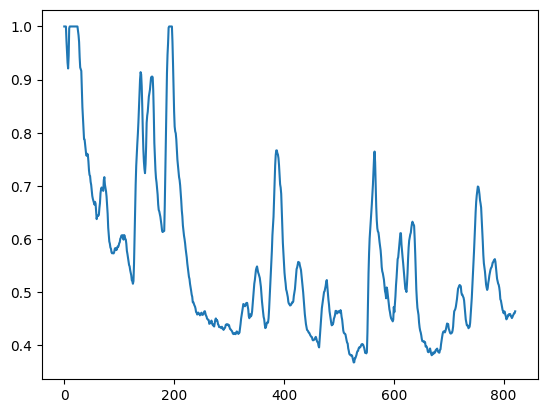

In [ ]:
plt.plot(caus_norm_av.iloc[:,195])
plt.show()

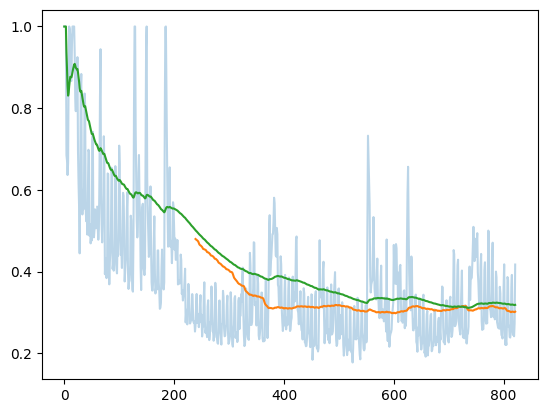

In [ ]:
roll = caus_norm_av.iloc[:,195].rolling(window=180).mean()
ema = caus_norm_av.iloc[:,195].ewm(span=400).mean()

roll2 = caus_norm_raw.iloc[:,195].rolling(window=180).mean()
ema2 = caus_norm_raw.iloc[:,195].ewm(span=400).mean()


plt.plot(caus_norm_raw.iloc[:,195], alpha=0.3)
plt.plot(roll2)
plt.plot(ema2)
plt.show()

## 4. Train/test split — by game

Data points are generated by sliding a window along each game's series, so points from the same game share information. Splitting *points* randomly would leak that shared information from train to test. We therefore split **by game**: 90% of games contribute training windows, 10% are held out entirely. The same reasoning motivates grouped cross-validation later.

### 4.1 Sanity checks

The six frames must stay column-aligned (same game order) for the split to be consistent:

In [ ]:
pre_covid_raw_t.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,111.875,70.666667,NaN,NaN,230.541667,243.243056,21.138889,272.041667,1310.829861,106.625,...,97.5,666.225694,59.833333,228.25,268.166667,NaN,932.975694,102.25,1114.118056,36.527778


In [ ]:
pre_covid_av_t.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,111.875,70.666667,NaN,NaN,230.541667,243.243056,21.138889,272.041667,1310.829861,106.625,...,97.5,666.225694,59.833333,228.25,268.166667,NaN,932.975694,102.25,1114.118056,36.527778


In [ ]:
causal_peaks_raw.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,111.875,70.666667,NaN,NaN,230.541667,243.243056,21.138889,272.041667,1310.829861,106.625,...,97.5,666.225694,59.833333,228.25,268.166667,NaN,932.975694,102.25,1114.118056,36.527778


In [ ]:
causal_peaks_av.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,111.875,70.666667,NaN,NaN,230.541667,243.243056,21.138889,272.041667,1310.829861,106.625,...,97.5,666.225694,59.833333,228.25,268.166667,NaN,932.975694,102.25,1114.118056,36.527778


In [ ]:
caus_norm_raw.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,0.999911,0.999859,NaN,NaN,0.999957,0.999959,0.999527,0.999963,0.999992,0.999906,...,0.999897,0.999985,0.999833,0.999956,0.999963,NaN,0.999989,0.999902,0.999991,0.999726


In [ ]:
caus_norm_av.head(1)

game_id,443110,324310,746910,407530,480650,211500,460810,201310,310950,307960,...,614860,363890,267530,626010,705220,467120,418460,230190,304390,296970
0,1.0,1.0,NaN,NaN,1.0,1.0,1.0,1.0,1.0,1.0,...,1.0,1.0,1.0,1.0,1.0,NaN,1.0,1.0,1.0,1.0


### 4.2 Shuffle and split

Shuffle the game order once (seeded, applied identically to every frame), then cut at the 90% boundary:

In [ ]:
# assemble dataframes into a dict
dataframes = {"pcr": pre_covid_raw_t,
              "pca": pre_covid_av_t,
              "cpr": causal_peaks_raw,
              "cpa": causal_peaks_av,
              "cnr": caus_norm_raw,
              "cna": caus_norm_av}

In [ ]:
shuffled = dict()

for key in dataframes:
    shuffled[key] = dataframes[key].sample(frac=1, axis=1, random_state=42)

In [ ]:
split_ratio = 0.9
n_games = len(shuffled["cpa"].columns)
tt_boundary = int(split_ratio * n_games)

## 5. Training examples

### 5.1 The extractor

`extractor` slides along one game's series producing `(window, target, game_id)` tuples:

- **window** — 56 days of causally normalised counts;
- **embargo** — 56 days between window end and target (the deployment scenario: forecasting ~2 months out);
- **target** — the mean *un-normalised* rolling average over the next 14 days, divided by the causal peak at the window end;
- missing days shift the cursor rather than producing imputed examples.

It also records the time index and the log causal peak at the window end as auxiliary features.

In [ ]:
def extractor(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    position = 0 
    l = len(time_series)
    
    while position + past_window + embargo + future_window - 1 < l:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[position + past_window + embargo: position + past_window + embargo + future_window]):
            position += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[position: position + past_window]):
            position += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            causal_peak_at_past = causal_peaks[position + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[position + past_window + embargo: position + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / causal_peak_at_past

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(causal_peak_at_past)

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[position: position + past_window],
                           avg,
                           game_id,
                           position + past_window - 1,
                           log_causal_peak))
            # shift along
            position += future_window

    return points

Generate points for every game (past 56, embargo 56, future 14):

In [ ]:
data = []

# generate data points
for column in shuffled["cna"]:
    game_id = column
    time_series = shuffled["cna"][column].tolist()
    causal_peaks = shuffled["cpa"][column].tolist()
    roll_average = shuffled["pca"][column].tolist()
    data.append(extractor(time_series, 56, 56, 14, causal_peaks, roll_average, game_id))

Sanity check — counts and one example:

In [ ]:
print("Number of games is " + str(len(data)))
print(len(data[0]))
print(len(data[0][0]))
print(len(data[0][0][0]))
print(data[0][0][1])
print(data[0][0][0])

Number of games is 1486
50
5
56
0.9990361783862705
[1.0, 0.9790185763304239, 0.9727999199060717, 0.9684186455024529, 0.9667919651227349, 0.9633153121994582, 0.9642801883247497, 0.9618564043287128, 0.9693200814288272, 0.9735084781243458, 0.9759350014603905, 0.9726140959246147, 0.9718547555419889, 0.9756240110155157, 0.9779998491737714, 0.9795942514403254, 0.9816294303579393, 0.983108112500764, 0.982512283886168, 0.9838180359564529, 0.9855827701085303, 0.98876897418942, 0.9867617501331566, 0.9877284682454363, 0.9911360358214378, 0.9946801271389177, 0.99856000184913, 0.9959768387868992, 0.9939424338133982, 0.9984271972708103, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 1.0, 0.9988830379228409, 1.0, 1.0, 1.0, 1.0, 0.9986285129902953, 0.9980669967292557, 0.9957356257077787, 0.9950199973565751, 0.9948503306270903, 0.9949935091193549, 0.9965422150929963, 0.997285206554452]


### 5.2 Train/test arrays

Split by game at the boundary, flatten the per-game lists, and unpack each tuple into the design matrix, target vector and group labels (game ids, used by `GroupKFold`):

In [ ]:
data_train = data[:tt_boundary]
data_test = data[tt_boundary:]

# flatten
data_train_f = [point for game in data_train for point in game]
data_test_f = [point for game in data_test for point in game]

print("There are " + str(len(data_test_f)) + " test data points.")
print("There are " + str(len(data_train_f)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in data_train_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in data_test_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
X_train.shape, Y_train.shape, X_test.shape, Y_test.shape

((66424, 58), (66424,), (7410, 58), (7410,))

### 5.3 Log target

The raw target distribution is heavily right-skewed (most windows sit far below peak). We model $\log(y + 0.01)$ instead — the offset guards against $\log 0$ for dead games:

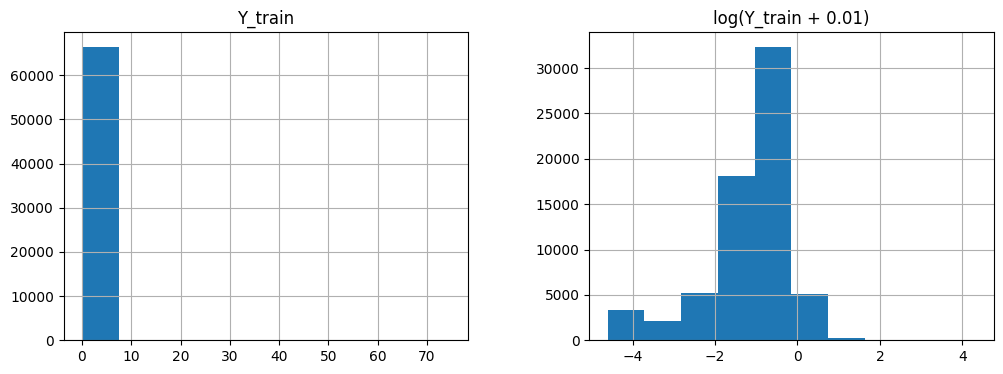

In [ ]:
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4))

pd.DataFrame(Y_train).hist(ax=ax1)
pd.DataFrame(np.log(Y_train + 0.01)).hist(ax=ax2)

ax1.set_title("Y_train")
ax2.set_title("log(Y_train + 0.01)")

plt.show()


In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

All model scores collect in one dictionary for the final comparison:

In [ ]:
model_scores = dict()

## 6. Baselines

### 6.1 Linear extrapolation

Extend the window's recent slope forward to the target period. This is the "obvious" forecast a spreadsheet would produce:

In [ ]:
def baseline0(x_train):
    pred = np.maximum(x_train[:, 55] + ((x_train[:,55] - x_train[:,5]) * (56 + 7) / 56.0) , 0.0)
    pred = np.log(pred + 0.01)
    return pred

In [ ]:
Y_pred = baseline0(X_train)

In [ ]:
from sklearn.metrics import root_mean_squared_error
score = root_mean_squared_error(Y_train_log, Y_pred)

print("The RMSE of this crude baseline model is: " + str(score))
model_scores["linear_extrapolation"] = score

The RMSE of this crude baseline model is: 1.1345824865214809


### 6.2 Dummy regressor

Predict the training-mean of the log target for every window — the "no information" reference. Note the honest result of this section: **linear extrapolation (1.13) is *worse* than the dummy (1.05)** — extrapolating short-term slopes nine weeks out amplifies noise.

In [ ]:
from sklearn.model_selection import GroupKFold
from sklearn.model_selection import cross_val_score
from sklearn.dummy import DummyRegressor

gkf = GroupKFold(n_splits = 5)
d_regressor = DummyRegressor(strategy="mean")

scores = cross_val_score(
    d_regressor,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The dummy regressor has a RMSE of: " + str(-np.mean(scores)))
model_scores["dummy"] = -np.mean(scores)

The dummy regressor has a RMSE of: 1.0522878232714674


## 7. Gradient-boosted trees (HistGBR)

`HistGradientBoostingRegressor` on the 58 features (56-day window + time index + log causal peak), default hyperparameters, grouped 5-fold CV:

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_regressor = HistGradientBoostingRegressor()

scores = cross_val_score(
    gb_regressor,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr"] = -np.mean(scores)

The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) has a RMSE of: 0.44714343393408684


### 7.1 Feature-reduction experiments

The HistGBR improves on the dummy immediately (1.05 → 0.447). How much of that skill needs the full window? First, drop features from the *recent* end (the slice keeps the oldest columns):

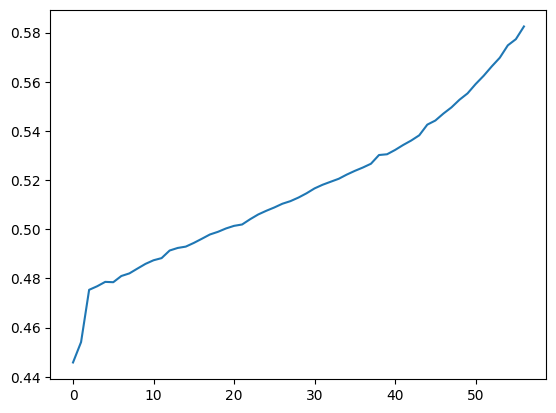

In [ ]:
# check how it does without the last two columns
n_features = len(X_train[0])
reduction = 20

reduced_scores = []

for reduction in range(57):
    scores = cross_val_score(
        gb_regressor,
        X_train[:,: n_features - reduction],
        Y_train_log,
        cv=gkf,
        groups=groups_train,
        scoring='neg_root_mean_squared_error'
    )
    score = -np.mean(scores)
    reduced_scores.append(score)

fig = plt.plot(reduced_scores)
plt.show()

*(Presentation note: `reduced_scores` already holds positive RMSEs, so this second plot — which negates them — is inverted. Kept for the record.)*

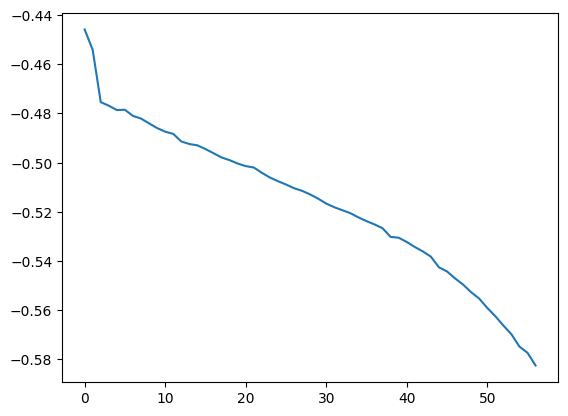

In [ ]:
errors = [-score for score in reduced_scores]
fig = plt.plot(errors)
plt.show()

Zoom on the last few removals — the auxiliary features and most recent days carry visible signal:

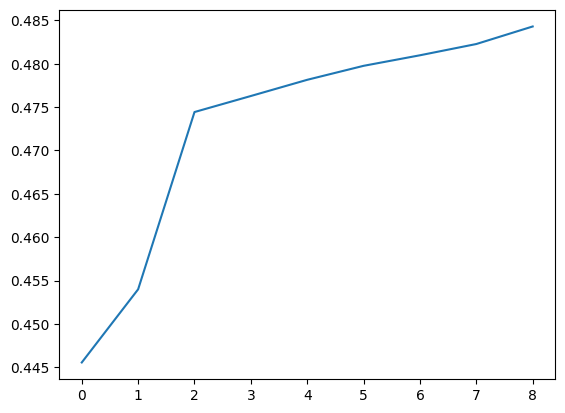

In [ ]:
n_features = len(X_train[0])

reduced_scores = []

for reduction in range(9):
    scores = cross_val_score(
        gb_regressor,
        X_train[:,: n_features - reduction],
        Y_train_log,
        cv=gkf,
        groups=groups_train,
        scoring='neg_root_mean_squared_error'
    )
    score = -np.mean(scores)
    reduced_scores.append(score)

fig = plt.plot(reduced_scores)
plt.show()

Only the last three features (most recent day + time + log peak):

In [ ]:
# check how it does with only the last three features

scores = cross_val_score(
    gb_regressor,
    X_train[:,-3:],
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)
score = -np.mean(scores)

print("The RMSE using only the last three features is: " + str(score))


The RMSE using only the last three features is: 0.5006625211260458


And the complementary experiment — grow the feature set from the recent end:

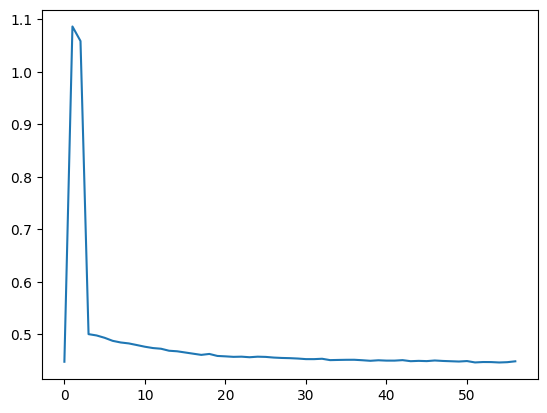

In [ ]:
# start increasing number features from end 

scores_reduced = []

for reduction in range(57):
    scores = cross_val_score(
        gb_regressor,
        X_train[:,-reduction:],
        Y_train_log,
        cv=gkf,
        groups=groups_train,
        scoring='neg_root_mean_squared_error'
    )
    score = -np.mean(scores)
    scores_reduced.append(score)

fig = plt.plot(scores_reduced)
plt.show()

**Finding.** Even two stale window columns achieve ~0.58 vs the dummy's 1.05: most of the model's skill is *level-tracking* (knowing where the game sits relative to its peak). The window's shape and recency contribute the final ~25% (0.58 → 0.447).

## 8. Decay-rate features

Can summaries of *pre-window* history help? We assume post-peak playercounts decay roughly exponentially, $\exp(-\lambda t)$, and add $\lambda$ as a feature.

### 8.1 Two-point estimate

First a crude estimate: time since the last causal peak, and $\lambda$ from the window-end value alone. The extractor also records `time_since_peak`:

In [ ]:
def extractor_decay(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    position = 0 
    l = len(time_series)
    
    while position + past_window + embargo + future_window - 1 < l:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[position + past_window + embargo: position + past_window + embargo + future_window]):
            position += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[position: position + past_window]):
            position += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            causal_peak_at_past = causal_peaks[position + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[position + past_window + embargo: position + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / causal_peak_at_past

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(causal_peak_at_past)

            # include the cna counts since the last peak before the window.
            index_of_window_end = position + past_window - 1
            peak_pointer = index_of_window_end
            prev_peak_found = False

            while peak_pointer > 0 and prev_peak_found == False:
                if time_series[peak_pointer] >= peak_threshold:
                    prev_peak_found = True
                
                else:
                    peak_pointer -= 1
            
            time_since_peak = index_of_window_end - peak_pointer
            lambd = - np.log(time_series[index_of_window_end] + 0.01) / (time_since_peak + 1)

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[position: position + past_window],
                           avg,
                           game_id,
                           position + past_window - 1,
                           log_causal_peak,
                           time_since_peak,
                           lambd))
            # shift along
            position += future_window

    return points

In [ ]:
data = []

# generate data points
for column in shuffled["cna"]:
    game_id = column
    time_series = shuffled["cna"][column].tolist()
    causal_peaks = shuffled["cpa"][column].tolist()
    roll_average = shuffled["pca"][column].tolist()
    data.append(extractor_decay(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:tt_boundary]
data_test = data[tt_boundary:]

# flatten
data_train_f = [point for game in data_train for point in game]
data_test_f = [point for game in data_test for point in game]

print("There are " + str(len(data_test_f)) + " test data points.")
print("There are " + str(len(data_train_f)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


Rebuild the arrays (now with `deepcopy` so re-running the cell cannot mutate the underlying points):

In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in data_train_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    series.append(point[6])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in data_test_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    series.append(point[6])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

In [ ]:
X_train[0]

array([ 1.00000000e+00,  9.79018576e-01,  9.72799920e-01,  9.68418646e-01,
        9.66791965e-01,  9.63315312e-01,  9.64280188e-01,  9.61856404e-01,
        9.69320081e-01,  9.73508478e-01,  9.75935001e-01,  9.72614096e-01,
        9.71854756e-01,  9.75624011e-01,  9.77999849e-01,  9.79594251e-01,
        9.81629430e-01,  9.83108113e-01,  9.82512284e-01,  9.83818036e-01,
        9.85582770e-01,  9.88768974e-01,  9.86761750e-01,  9.87728468e-01,
        9.91136036e-01,  9.94680127e-01,  9.98560002e-01,  9.95976839e-01,
        9.93942434e-01,  9.98427197e-01,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  9.98883038e-01,
        1.00000000e+00,  1.00000000e+00,  1.00000000e+00,  1.00000000e+00,
        9.98628513e-01,  9.98066997e-01,  9.95735626e-01,  9.95019997e-01,
        9.94850331e-01,  

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_regressor = HistGradientBoostingRegressor()

scores = cross_val_score(
    gb_regressor,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) and decay rate has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr_decay"] = -np.mean(scores)

The histgb regressor using the 56 playercounts and time of window and log(causal peak at window) and decay rate has a RMSE of: 0.4441300074843052


### 8.2 Log-linear fit (polyfit)

The two-point estimate is noisy — a least-squares slope of $\log(\text{cna})$ over the whole post-peak segment uses all the information between peak and window:

In [ ]:
def extractor_decay_polyfit(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    position = 0 
    l = len(time_series)
    
    while position + past_window + embargo + future_window - 1 < l:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[position + past_window + embargo: position + past_window + embargo + future_window]):
            position += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[position: position + past_window]):
            position += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            causal_peak_at_past = causal_peaks[position + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[position + past_window + embargo: position + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / causal_peak_at_past

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(causal_peak_at_past)

            # include the cna counts since the last peak before the window.
            index_of_window_end = position + past_window - 1
            peak_pointer = index_of_window_end
            prev_peak_found = False

            while peak_pointer > 0 and prev_peak_found == False:
                if time_series[peak_pointer] >= peak_threshold:
                    prev_peak_found = True
                
                else:
                    peak_pointer -= 1
            
            series_since_peak = np.array(time_series[peak_pointer: index_of_window_end + 1])
            time_since_peak = np.arange(len(series_since_peak))

            # the tilde flips T and F:
            mask = ~np.isnan(time_since_peak)

            if mask.sum() > 1:
                lam = - np.polyfit(time_since_peak, np.log(series_since_peak + 0.01), 1)[0]
            else:
                lam = 0.0

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[position: position + past_window],
                           avg,
                           game_id,
                           position + past_window - 1,
                           log_causal_peak,
                           lam
                           ))
            # shift along
            position += future_window

    return points

In [ ]:
data = []

# generate data points
for column in shuffled["cna"]:
    game_id = column
    time_series = shuffled["cna"][column].tolist()
    causal_peaks = shuffled["cpa"][column].tolist()
    roll_average = shuffled["pca"][column].tolist()
    data.append(extractor_decay_polyfit(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0))

In [ ]:
data_train = data[:tt_boundary]
data_test = data[tt_boundary:]

# flatten
data_train_f = [point for game in data_train for point in game]
data_test_f = [point for game in data_test for point in game]

print("There are " + str(len(data_test_f)) + " test data points.")
print("There are " + str(len(data_train_f)) + " train data points.")

There are 7410 test data points.
There are 66424 train data points.


In [ ]:
len(data_train_f[0])

6

In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in data_train_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in data_test_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_regressor = HistGradientBoostingRegressor()

scores = cross_val_score(
    gb_regressor,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using polyfit decay rate has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr_decay"] = -np.mean(scores)

The histgb regressor using polyfit decay rate has a RMSE of: 0.4446341710328392


**Finding.** Neither decay feature moves the score beyond fold noise (0.4471 → 0.4441 / 0.4455, fold std ≈ 0.013). Given the current level and recent trend, older history adds nothing — the trajectories are effectively Markovian.

### 8.3 Hyperparameter search

Is the model capacity-limited instead? A 40-draw randomised search over seven hyperparameters:

In [ ]:
from scipy.stats import loguniform, randint, uniform
from sklearn.model_selection import RandomizedSearchCV, GroupKFold
from sklearn.ensemble import HistGradientBoostingRegressor

param_distributions = {
    "learning_rate":     loguniform(0.01, 0.3),     # default 0.1
    "max_iter":          randint(100, 1000),        # default 100 — likely too few at low learning rates
    "max_leaf_nodes":    [15, 31, 63, 127, 255],    # default 31 — tree capacity
    "max_depth":         [None, 4, 6, 8, 12],       # None = unlimited (depth governed by leaf count)
    "min_samples_leaf":  randint(5, 200),           # default 20 — regularization against tiny leaves
    "l2_regularization": loguniform(1e-3, 10),      # default 0
    "max_features":      uniform(0.5, 0.5),         # fraction of features per split, 0.5–1.0
}

search = RandomizedSearchCV(
    HistGradientBoostingRegressor(early_stopping=False, random_state=0),
    param_distributions,
    n_iter=40,
    scoring="neg_root_mean_squared_error",
    cv=GroupKFold(n_splits=5),
    random_state=0,
    n_jobs=-1,
    verbose=1,
)

search.fit(X_train, Y_train_log, groups=groups_train)

print("Best CV RMSE: ", -search.best_score_)
print("Default-params RMSE was ~0.4455 — improvement:", 0.4455 - (-search.best_score_))
print("Best params:", search.best_params_)


Fitting 5 folds for each of 40 candidates, totalling 200 fits
Best CV RMSE:  0.44164520945062097
Default-params RMSE was ~0.4455 — improvement: 0.003854790549379039
Best params: {'l2_regularization': np.float64(0.019230428678296146), 'learning_rate': np.float64(0.021224223737482065), 'max_depth': 8, 'max_features': np.float64(0.6837809350239483), 'max_iter': 391, 'max_leaf_nodes': 127, 'min_samples_leaf': 37}


In [ ]:
results = pd.DataFrame(search.cv_results_)
cols = ["mean_test_score", "std_test_score"] + [c for c in results.columns if c.startswith("param_")]
top = results[cols].sort_values("mean_test_score", ascending=False).head(10)
top["mean_test_score"] = -top["mean_test_score"]   # back to positive RMSE
top


,mean_test_score,std_test_score,param_l2_regularization,param_learning_rate,param_max_depth,param_max_features,param_max_iter,param_max_leaf_nodes,param_min_samples_leaf
24,0.441645,0.012575,0.019230,0.021224,8,0.683781,391,127,37
26,0.442689,0.012337,0.107960,0.017638,8,0.932467,641,127,40
39,0.443082,0.011027,0.006759,0.042395,None,0.607440,563,127,9
1,0.443522,0.012886,0.034477,0.027510,None,0.981831,414,31,44
10,0.443638,0.011873,0.212521,0.040933,12,0.622213,891,15,54
25,0.444490,0.014241,0.002502,0.033144,8,0.920570,768,15,7
33,0.444575,0.013405,0.008122,0.023753,8,0.528209,757,63,97
22,0.445048,0.012522,0.075950,0.114217,None,0.691731,141,63,45
14,0.445095,0.013011,0.007367,0.068368,12,0.632695,511,31,63
19,0.445181,0.013657,6.471367,0.045757,12,0.989285,239,255,91


**Finding.** Best 0.4416 — under one standard error of fold noise, and the top-10 configurations span a 100× capacity range within 0.003 of each other. The loss surface is flat: defaults were already at the ceiling.

### 8.4 Denser stride

Does more data help? Halving the extraction stride (14 → 7) doubles the training set with overlapping windows, holding the target definition fixed (`stride` is a separate parameter precisely so the target does not change):

In [ ]:
def extractor_decay_polyfit_stride(time_series, past_window, embargo, future_window, causal_peaks, roll_average, game_id, peak_threshold, stride):
    """
    Takes as an input a list of player count values and returns a list of training examples.

    Args:
    time_series (list): a list of player count values in the past normalised by causal peak
    past_window (int): length of past playercounts window used for generating a data point
    embargo (int): length of gap between past window end and future window.
    future_window(int): length of future window from which target average playercount is computed.
    causal_peaks (list): causal peaks of rolling averaged playercounts
    roll_average(list):  rolling averages of playercounts
    game_id (int): an identifier for each game used to perform splits later
    peak_threshold (float): fraction of 1 - the threshold for designating a past normalised playercount as a 'peak'

    Returns: list of tuples (window (list), future average (float)) 
    """
    points = []
    position = 0 
    l = len(time_series)
    
    while position + past_window + embargo + future_window - 1 < l:
        # if nan in future window, then shift

        if any(pd.isna(ele) for ele in time_series[position + past_window + embargo: position + past_window + embargo + future_window]):
            position += future_window

        # elif nan in past window, then shift
        elif any(pd.isna(ele) for ele in time_series[position: position + past_window]):
            position += past_window

        # else, create a datapoint
        else:
            # take the causal peak at the end of the past window
            causal_peak_at_past = causal_peaks[position + past_window - 1]

            # compute the average of the non-normalised playercounts at the future window
            avg = sum(roll_average[position + past_window + embargo: position + past_window + embargo + future_window]) / float(future_window)

            # normalise this by the causal peak at the end of past window
            avg = avg / causal_peak_at_past

            # include the log of the historical peak of the game at the time of window
            log_causal_peak = np.log(causal_peak_at_past)

            # include the cna counts since the last peak before the window.
            index_of_window_end = position + past_window - 1
            peak_pointer = index_of_window_end
            prev_peak_found = False

            while peak_pointer > 0 and prev_peak_found == False:
                if time_series[peak_pointer] >= peak_threshold:
                    prev_peak_found = True
                
                else:
                    peak_pointer -= 1
            
            series_since_peak = np.array(time_series[peak_pointer: index_of_window_end + 1])
            time_since_peak = np.arange(len(series_since_peak))

            # the tilde flips T and F:
            mask = ~np.isnan(time_since_peak)

            if mask.sum() > 1:
                lam = - np.polyfit(time_since_peak, np.log(series_since_peak + 0.01), 1)[0]
            else:
                lam = 0.0

            # append the data with the time series of causally normalised past playercounts and the future average
            points.append((time_series[position: position + past_window],
                           avg,
                           game_id,
                           position + past_window - 1,
                           log_causal_peak,
                           lam
                           ))
            # shift along
            position += stride

    return points

In [ ]:
data = []

# generate data points
for column in shuffled["cna"]:
    game_id = column
    time_series = shuffled["cna"][column].tolist()
    causal_peaks = shuffled["cpa"][column].tolist()
    roll_average = shuffled["pca"][column].tolist()
    data.append(extractor_decay_polyfit_stride(time_series, 56, 56, 14, causal_peaks, roll_average, game_id, 1.0, 7))

In [ ]:
data_train = data[:tt_boundary]
data_test = data[tt_boundary:]

# flatten
data_train_f = [point for game in data_train for point in game]
data_test_f = [point for game in data_test for point in game]

print("There are " + str(len(data_test_f)) + " test data points.")
print("There are " + str(len(data_train_f)) + " train data points.")

There are 14820 test data points.
There are 132848 train data points.


In [ ]:
x_train = []
y_train = []
groups_train = []

x_test = []
y_test = []
groups_test = []

for point in data_train_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_train.append(series)
    y_train.append(point[1])
    groups_train.append(point[2])

for point in data_test_f:
    series = deepcopy(point[0])
    series.append(point[3])
    series.append(point[4])
    series.append(point[5])
    x_test.append(series)
    y_test.append(point[1])
    groups_test.append(point[2])

X_train = np.array(x_train)
Y_train = np.array(y_train)

X_test = np.array(x_test)
Y_test = np.array(y_test)

In [ ]:
Y_test_log = np.log(Y_test + 0.01)
Y_train_log = np.log(Y_train + 0.01)

In [ ]:
from sklearn.ensemble import HistGradientBoostingRegressor

gb_regressor = HistGradientBoostingRegressor()

scores = cross_val_score(
    gb_regressor,
    X_train,
    Y_train_log,
    cv=gkf,
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print("The histgb regressor using polyfit decay rate has a RMSE of: " + str(-np.mean(scores)))
model_scores["histgbr_decay_stride7"] = -np.mean(scores)

The histgb regressor using polyfit decay rate has a RMSE of: 0.4469183269016515


**Finding.** No significant change — overlapping windows are near-duplicates of games the model already knows. Together, sections 7–8 point one way: **~0.445 is an information ceiling of window-only features, not a modelling limitation.**

## 9. Error analysis

Where does the remaining error live? Out-of-fold predictions for every training window (each predicted by a model that never saw its game):

In [ ]:
from sklearn.model_selection import cross_val_predict

predictions = cross_val_predict(HistGradientBoostingRegressor(),
                  X_train,
                  Y_train_log,
                  groups = groups_train,
                  cv = GroupKFold(n_splits=5)
)

In [ ]:
scores = cross_val_score(
    HistGradientBoostingRegressor(),
    X_train,
    Y_train_log,
    cv=GroupKFold(n_splits=5),
    groups=groups_train,
    scoring='neg_root_mean_squared_error'
)

print(-scores.mean())

0.44526272005415957


Split windows into *big errors* (absolute log-residual > 1, i.e. off by more than a factor of ~2.7) and the rest, then compare their feature distributions:

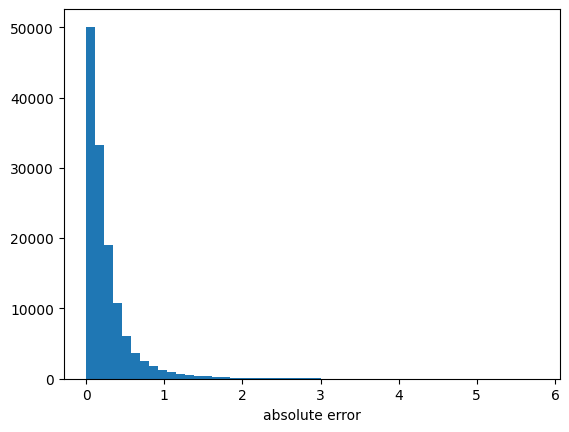

In [ ]:
residuals = np.abs(predictions - Y_train_log)
fig, ax = plt.subplots()
plt.hist(residuals, bins=50)
ax.set_xlabel(xlabel="absolute error")
plt.show()

residuals = np.abs(predictions - Y_train_log)

mask = residuals > 1.0            # boolean array
X_big_errors  = X_train[mask]     # rows where error > 1
X_small_errors = X_train[~mask]   # everything else

In [ ]:
big_error_eow = X_big_errors[:,56]
big_error_lcp = X_big_errors[:,57]
big_error_lam = X_big_errors[:,58]

small_error_eow = X_small_errors[:,56]
small_error_lcp = X_small_errors[:,57]
small_error_lam = X_small_errors[:,58]

Time of window end:

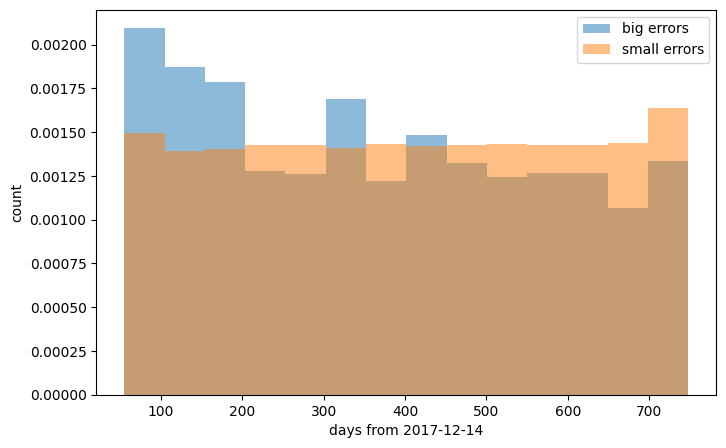

In [ ]:
a = big_error_eow
b = small_error_eow

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    15
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)

ax.set_xlabel("days from 2017-12-14")
ax.set_ylabel("count")
ax.legend()
plt.show()

It would seem that a lot of the big errors come from windows near the start of the recording period. This plausibly reflects selection bias — games were chosen for being popular around the collection start, so the early sample is enriched with games at their hype peak, not in steady state — compounded by the causal normalisation having little history to work with early on.

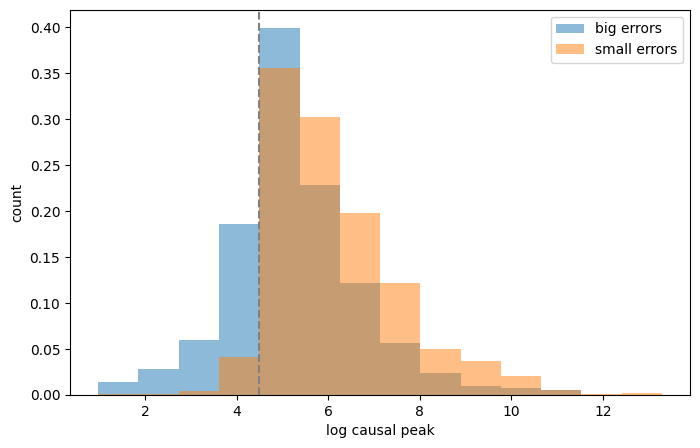

In [ ]:
a = big_error_lcp
b = small_error_lcp

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    15
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)
ax.axvline(x=4.5, linestyle="--", color="grey")

ax.set_xlabel("log causal peak")
ax.set_ylabel("count")
ax.legend()
plt.show()

Smaller-error points tend to have a larger log causal peak; below ~4.5 (peaks under ~90 players) big errors dominate. Prediction error rises as the playercount shrinks — in log space, integer-level noise on small games is proportionally huge.

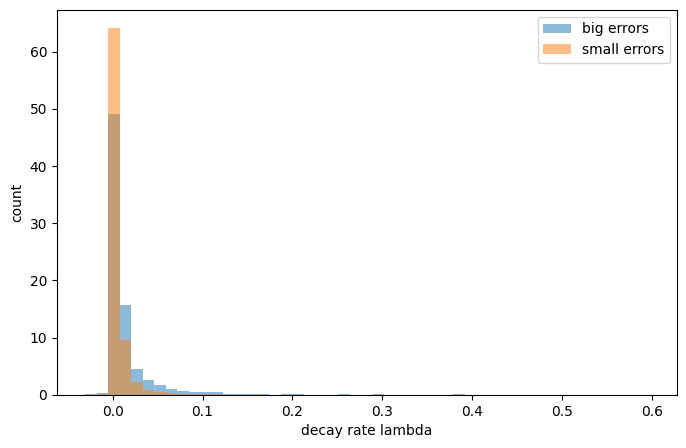

In [ ]:
a = big_error_lam[~np.isnan(big_error_lam)]
b = small_error_lam[~np.isnan(small_error_lam)]

fig, ax = plt.subplots(figsize=(8, 5))

bins = np.linspace(
    min(a.min(), b.min()),
    max(a.max(), b.max()),
    50
)   # shared edges so the bars line up

ax.hist(a, bins=bins, alpha=0.5, label="big errors", density=True)
ax.hist(b, bins=bins, alpha=0.5, label="small errors", density=True)

ax.set_xlabel("decay rate lambda")
ax.set_ylabel("count")
ax.legend()
plt.show()

Higher fitted decay rates also associate with higher errors — mid-collapse games are intrinsically hard to extrapolate nine weeks out.

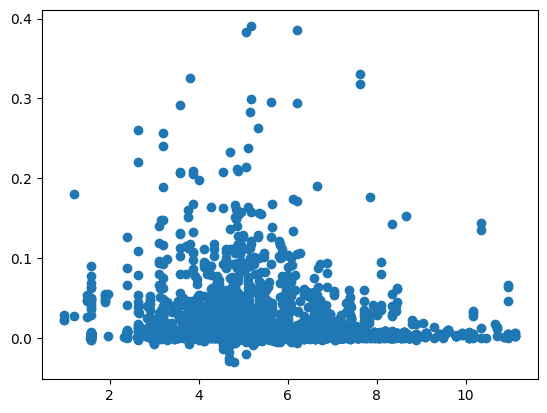

In [ ]:
plt.scatter(big_error_lcp, big_error_lam)
plt.show()

## 10. Tag features (in progress)

Static metadata — genre/feature tags per game — is the first information source from *outside* the playercount series. Frequency survey and alignment with the games kept by the dud filter:

In [ ]:
tag_path = Path("../data/mendeley/applicationTags.csv")
tags = pd.read_csv(tag_path, header=None)

# extract the tags only
tags_only = tags.iloc[:,1:]
# make all tags lowercase
tags_only = tags_only.map(lambda x: x.lower() if isinstance(x, str) else x)
tags_only = tags_only.stack()

counts = tags_only.value_counts()

counts.iloc[:5]


singleplayer    1335
action          1268
adventure       1091
multiplayer     1041
indie            954
Name: count, dtype: int64

In [ ]:
tags = tags.T
new_head = tags.iloc[0]
tags = tags[1:]
tags.columns = new_head
tags.head()

,578080,570,730,622590,359550,271590,238960,230410,440,252950,...,568570,562760,394690,64000,227860,34000,202480,429050,209650,304730
1,Survival,Free to Play,FPS,NaN,FPS,Open World,Free to Play,Free to Play,Free to Play,Multiplayer,...,Crafting,Indie,Early Access,Strategy,Strategy,NaN,NaN,Early Access,Dog,Simulation
2,Shooter,MOBA,Multiplayer,NaN,Multiplayer,Action,Action RPG,Action,Multiplayer,Racing,...,Survival,Casual,Mini Golf,World War II,Building,NaN,NaN,Simulation,FPS,Trains
3,Multiplayer,Strategy,Shooter,NaN,Tactical,Multiplayer,RPG,Co-op,FPS,Soccer,...,Open World,Simulation,Massively Multiplayer,Tactical,Sandbox,NaN,NaN,Underwater,Action,Management
4,PvP,Multiplayer,Action,NaN,Action,Third Person,Hack and Slash,Multiplayer,Action,Sports,...,Sandbox,NaN,Casual,War,Indie,NaN,NaN,Multiplayer,Multiplayer,Strategy
5,FPS,Team-Based,Team-Based,NaN,Shooter,First-Person,Multiplayer,Third-Person Shooter,Shooter,Competitive,...,Simulation,NaN,Character Customization,RTS,Survival,NaN,NaN,Action,Shooter,Economy


In [ ]:
all_cols = new_head.tolist()
kept_cols = [int(i) for i in shuffled["cna"].columns.tolist()]
dropped_cols = [col for col in all_cols if col not in kept_cols]

In [ ]:
tags = tags.drop(columns=dropped_cols)
tags.head()

,578080,570,730,622590,359550,271590,238960,230410,440,252950,...,568570,562760,394690,64000,227860,34000,202480,429050,209650,304730
1,Survival,Free to Play,FPS,NaN,FPS,Open World,Free to Play,Free to Play,Free to Play,Multiplayer,...,Crafting,Indie,Early Access,Strategy,Strategy,NaN,NaN,Early Access,Dog,Simulation
2,Shooter,MOBA,Multiplayer,NaN,Multiplayer,Action,Action RPG,Action,Multiplayer,Racing,...,Survival,Casual,Mini Golf,World War II,Building,NaN,NaN,Simulation,FPS,Trains
3,Multiplayer,Strategy,Shooter,NaN,Tactical,Multiplayer,RPG,Co-op,FPS,Soccer,...,Open World,Simulation,Massively Multiplayer,Tactical,Sandbox,NaN,NaN,Underwater,Action,Management
4,PvP,Multiplayer,Action,NaN,Action,Third Person,Hack and Slash,Multiplayer,Action,Sports,...,Sandbox,NaN,Casual,War,Indie,NaN,NaN,Multiplayer,Multiplayer,Strategy
5,FPS,Team-Based,Team-Based,NaN,Shooter,First-Person,Multiplayer,Third-Person Shooter,Shooter,Competitive,...,Simulation,NaN,Character Customization,RTS,Survival,NaN,NaN,Action,Shooter,Economy


## 11. Summary of results

| Model | CV RMSE (log target) | Note |
|---|---|---|
| Dummy (mean) | 1.052 | no-information reference |
| Linear extrapolation | 1.135 | worse than dummy |
| HistGBR — window + time + log peak | 0.4471 | default hyperparameters |
| + time-since-peak + two-point λ | 0.4441 | within fold noise |
| + polyfit λ | 0.4455 | within fold noise |
| HistGBR, tuned (40-draw search) | 0.4416 | within fold noise |
| HistGBR, stride 7 (2× data) | 0.4460 | within fold noise |

Fold-to-fold std is ≈ 0.013, so differences under ~0.005 are noise.

**Conclusions.** The model roughly halves the multiplicative forecast error versus the no-information baseline (×/÷2.9 → ×/÷1.6). Feature ablations, decay summaries, tuning and data-doubling all land within noise of 0.445 — the information ceiling of playercount-history features at this horizon. The residual error concentrates where the target is intrinsically noisiest: small games, early-collection windows, and games mid-collapse. See `report/progress_report.qmd` for the full write-up and `player_forecast/` for the productised pipeline.